# 01. Quality control and strong / weak perturbations (Fig. S2F, S2G, S2I, S2J)

Perturbations are classified with the criteria of the paper's STAR Methods ("Functional analyses of strong perturbations"):

- **strong**: at least 50 differentially expressed genes (Anderson-Darling, BH-corrected p < 0.05), at least 25 cells passing QC, and an on-target knockdown of at least 30% (or the target not detected);
- **weak**: the same, but fewer than 5 differentially expressed genes;
- **intermediate**: 5-49 differentially expressed genes;
- **excluded**: fewer than 25 cells or insufficient knockdown.

In [1]:
import sys; sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import pandas as pd
import gwps

gw = gwps.load("k562_gw")
ess = gwps.load("k562_ess")
for a in (gw, ess):
    a.obs["class"] = gwps.classify(a.obs)

counts = pd.DataFrame({"K562 genome-wide": gw.obs["class"].value_counts(),
                       "K562 essential": ess.obs["class"].value_counts()}).fillna(0).astype(int)
counts

,K562 genome-wide,K562 essential
class,,
control,585,109
excluded,1123,193
intermediate,1746,350
strong,1962,1101
weak,5842,532


The paper reports 1,973 strong perturbations in the K562 genome-wide screen.

In [2]:
gw.obs[["target", "class"]].to_csv(gwps.RES / "k562_gw_classes.csv")
ess.obs[["target", "class"]].to_csv(gwps.RES / "k562_ess_classes.csv")

## Report Fig. 1: strong and weak perturbations (cf. paper Fig. S2G, S2I, S2J)

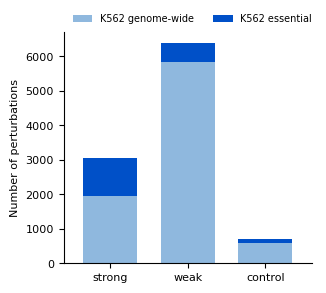

In [3]:
order = ["strong", "weak", "control"]
fig, ax = plt.subplots(figsize=(3.2, 3))
counts.loc[order, ["K562 genome-wide", "K562 essential"]].plot.bar(ax=ax, stacked=True, color=["#8fb8de", "#0050c8"], width=0.7)
ax.set_ylabel("Number of perturbations"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2)
gwps.savefig(fig, "fig01a_strong_weak_counts")

`pct_expr = -1` means the target was not detected in the perturbed cells (100% knockdown) and is kept;
perturbations whose target was not detected in control cells (`pct_expr` NaN) have no knockdown value.

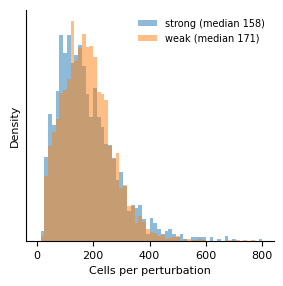

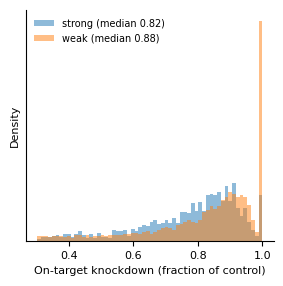

In [4]:
o = gw.obs[gw.obs["class"].isin(["strong", "weak"])]
for col, xlabel, rng, name in [("num_cells_filtered", "Cells per perturbation", (0, 800), "fig01b_cells"),
                               ("pct_expr", "On-target knockdown (fraction of control)", (0.3, 1), "fig01c_knockdown")]:
    fig, ax = plt.subplots(figsize=(3.2, 3))
    for cls, colour in [("strong", "#1f77b4"), ("weak", "#ff7f0e")]:
        x = o.loc[o["class"] == cls, col].dropna()
        x = -x if col == "pct_expr" else x
        ax.hist(x, bins=60, range=rng, alpha=0.5, density=True, color=colour, label=f"{cls} (median {x.median():.2f})"
                if col == "pct_expr" else f"{cls} (median {x.median():.0f})")
    ax.set_xlabel(xlabel); ax.set_ylabel("Density"); ax.set_yticks([]); ax.legend(frameon=False)
    gwps.savefig(fig, name)

## Report Fig. 2: KEGG enrichment of strong and weak perturbations (cf. paper Fig. S2F)

Background: all genes targeted in the genome-wide screen.

strong: 20 KEGG terms with adj. P < 0.05


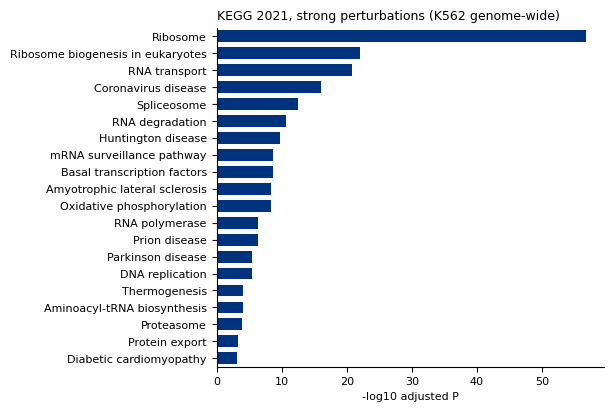

weak: 3 KEGG terms with adj. P < 0.05


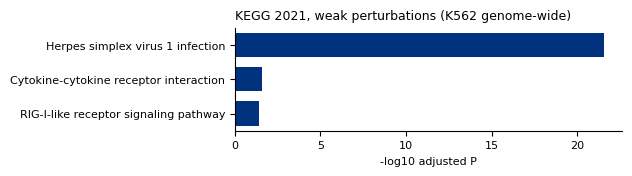

In [5]:
background = gw.obs.loc[~gw.obs["is_control"], "target"].unique()
enr = {cls: gwps.enrich(gw.obs.loc[gw.obs["class"] == cls, "target"].unique(), background, top=20)
       for cls in ["strong", "weak"]}
for cls, res in enr.items():
    print(f"{cls}: {len(res)} KEGG terms with adj. P < 0.05")
    gwps.enrich_barplot(res, f"KEGG 2021, {cls} perturbations (K562 genome-wide)", f"fig02{'ab'[cls == 'weak']}_kegg_{cls}")

In [6]:
weak_top = enr["weak"].iloc[0]
zf = [g for g in weak_top["Genes"].split(";") if g.startswith(("ZNF", "ZSCAN", "ZKSCAN", "ZFP"))]
print(f"weak, top term '{weak_top['Term']}': {len(zf)} of {len(weak_top['Genes'].split(';'))} genes are zinc-finger genes")

weak, top term 'Herpes simplex virus 1 infection': 273 of 337 genes are zinc-finger genes
